# Model Extent Polygons (1D, 2D, and Overall Footprints)

HEC-RAS models cover a real footprint on the ground: the perimeters of the 2D flow
areas plus the corridor swept by the 1D cross sections. This notebook shows how to
build those footprints as **true polygons** directly from the geometry HDF, rather
than a rectangular bounding box.

## What you'll learn

- Read 2D flow-area perimeters with `HdfMesh.get_mesh_areas()`.
- Generate 1D river **edge lines** from cross-section end points with
  `HdfXsec.generate_river_edge_lines()` (the pure-Python equivalent of RASMapper's
  *Create Edge Lines at XS Limits*).
- Build the 1D reach **footprint** polygon(s) with `HdfXsec.get_1d_footprint()`.
- Get the **true model extent** polygon (1D + 2D, multipart) from the upgraded
  `HdfProject.get_project_extent(..., geometry_type='footprint')`, and compare it to
  the legacy buffered bounding box.
- Slice the extent into **1D-only** and **2D-only** footprints with the `include_1d`
  / `include_2d` flags.

## Prerequisites

- `ras-commander` with `geopandas` / `shapely` (installed dependencies).
- Internet access on first run (downloads the HEC-RAS example projects).
- No HEC-RAS execution is required — everything is read from the geometry HDF.

In [1]:
import sys
import logging
from pathlib import Path

# Prefer the local repository source so the newest extent APIs are available even
# when an older ras-commander is pip-installed. Walk up from the notebook location
# until we find the package, then put that repo root first on sys.path.
_here = Path.cwd()
for _cand in [_here, *_here.parents]:
    if (_cand / "ras_commander" / "__init__.py").exists():
        sys.path.insert(0, str(_cand))
        break

import matplotlib.pyplot as plt

import ras_commander
from ras_commander import RasExamples, init_ras_project
from ras_commander.hdf import HdfXsec, HdfMesh, HdfProject, HdfStruc

# Quiet the library's informational logging so the demo output stays readable.
# (Geometries without 1D cross sections log a handled error while we scan for the
# right one; real failures still raise exceptions.)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

print("ras_commander:", ras_commander.__file__)


def extract_or_reuse(name, suffix):
    """Reuse an already-extracted example project if present, else extract it.

    Keeps notebook re-runs fast; still downloads/extracts on a fresh machine.
    """
    dest = Path.cwd() / "example_projects" / f"{name}_{suffix}"
    if dest.exists() and any(dest.glob("*.prj")):
        return dest
    return RasExamples.extract_project(name, suffix=suffix)


def find_geom_hdfs(project_folder):
    """Return the geometry HDF files (*.g##.hdf) in a project folder, sorted."""
    return sorted(Path(project_folder).glob("*.g[0-9][0-9].hdf"))


def describe(gdf, label):
    """Compact one-line summary of a geometry GeoDataFrame."""
    if gdf is None or len(gdf) == 0:
        print(f"  {label}: (empty)")
        return
    gtypes = sorted(set(gdf.geom_type))
    try:
        area = float(gdf.geometry.area.sum())
    except Exception:
        area = float("nan")
    print(f"  {label}: rows={len(gdf)} types={gtypes} area={area:,.0f} valid={bool(gdf.geometry.is_valid.all())}")

c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ras_commander: C:\Users\bill\AppData\Local\Temp\rc-extent\ras_commander\__init__.py


## Example 1: Combined 1D + 2D model (Bald Eagle Creek Multi-2D)

This model has a 1D river reach *and* several 2D flow areas, so it exercises every
part of the extent API: 2D perimeters, a 1D reach footprint, and the unified overall
extent.

In [2]:
project = extract_or_reuse("BaldEagleCrkMulti2D", "extent_demo")
ras = init_ras_project(project, "6.6")

# Pick the geometry HDF that carries both 2D areas and 1D cross sections.
geom_hdf = None
for candidate in find_geom_hdfs(project):
    names = HdfMesh.get_mesh_area_names(candidate)
    xs = HdfXsec.get_cross_sections(candidate)
    if names and not xs.empty:
        geom_hdf = candidate
        break
geom_hdf = geom_hdf or find_geom_hdfs(project)[0]
print("Geometry HDF:", geom_hdf.name)
print("2D area names:", HdfMesh.get_mesh_area_names(geom_hdf))

Geometry HDF: BaldEagleDamBrk.g06.hdf
2D area names: ['193', '194', 'LockHaven']


### 2D flow-area perimeters

`HdfMesh.get_mesh_areas()` returns one perimeter polygon per 2D flow area, already
carrying the project CRS. Multiple areas become multiple rows.

In [3]:
mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
print("CRS:", mesh_areas.crs)
describe(mesh_areas, "2D perimeters (per area)")
mesh_areas[["mesh_name", "geometry"]]

CRS: EPSG:2271
  2D perimeters (per area): rows=3 types=['Polygon'] area=172,401,558 valid=True


,mesh_name,geometry
0,193,"POLYGON ((2042744.054 340037.055, 2042059.203 ..."
1,194,"POLYGON ((2013482.56 332510.738, 2013482.172 3..."
2,LockHaven,"POLYGON ((2045454.816 349795.754, 2045592.698 ..."


### 1D edge lines and the reach footprint

The 1D footprint is the corridor between the left and right **edge lines**, closed at
each end by the upstream and downstream cross sections. If the geometry already stores
`Geometry/River Edge Lines`, those are used; otherwise `get_1d_footprint()` generates
them on the fly from the cross-section end points (`generate_river_edge_lines()`).

The end caps follow the **real cut-line geometry** of the end cross sections, interior
vertices included, so a bent cut line is reproduced rather than chorded straight across.
Pass `close_with_end_xs=False` for the legacy straight-chord closure.

In [4]:
stored_edges = HdfXsec.get_river_edge_lines(geom_hdf)
generated_edges = HdfXsec.generate_river_edge_lines(geom_hdf)
describe(stored_edges, "stored edge lines")
describe(generated_edges, "generated edge lines (fallback)")

# Per-reach footprint polygons, and the dissolved (multipart) version.
footprint_1d = HdfXsec.get_1d_footprint(geom_hdf, dissolve=False)
footprint_1d_dissolved = HdfXsec.get_1d_footprint(geom_hdf, dissolve=True)
describe(footprint_1d, "1D footprint (per reach)")
describe(footprint_1d_dissolved, "1D footprint (dissolved)")
footprint_1d[["River", "Reach", "source", "geometry"]]

  stored edge lines: (empty)
  generated edge lines (fallback): rows=2 types=['LineString'] area=0 valid=True


  1D footprint (per reach): rows=1 types=['Polygon'] area=707,534,339 valid=True


  1D footprint (dissolved): rows=1 types=['Polygon'] area=707,534,339 valid=True


,River,Reach,source,geometry
0,Bald Eagle Cr.,Lock Haven,generated_edge_lines,"POLYGON ((1966056.938 291992.687, 1966305.15 2..."


#### Visualizing the edge lines and the 1D extent

The left panel colors the **left and right edge lines** (`bank_side`) that bound each reach, with the cross-section cut lines between them and the closed reach footprint underneath. The right panel is the **1D-only extent** (`get_project_extent(include_2d=False)`) over the same cross sections — the corridor the 1D model actually occupies, with no 2D area mixed in.

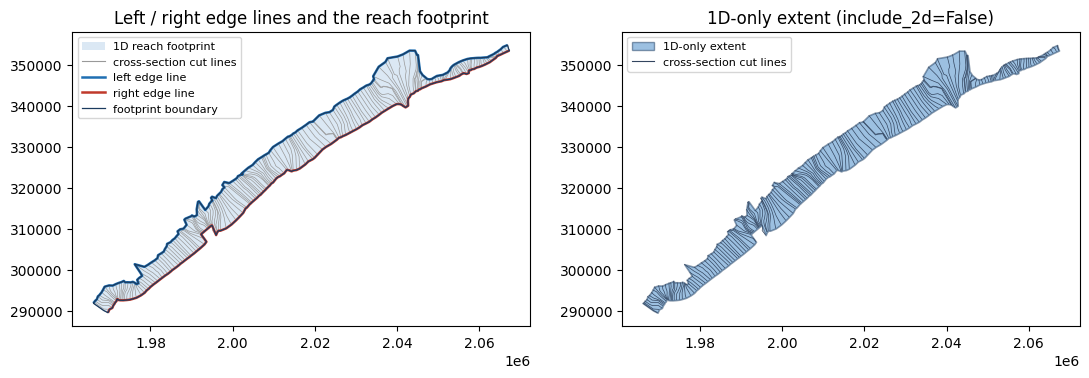

Edge lines: 1 left, 1 right; 1D-only extent parts: 1


In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

left_edges = generated_edges[generated_edges["bank_side"] == "Left"]
right_edges = generated_edges[generated_edges["bank_side"] == "Right"]
extent_1d, _ = HdfProject.get_project_extent(geom_hdf, include_2d=False, buffer_percent=0.0)
xs_be = HdfXsec.get_cross_sections(geom_hdf)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6))

# Left: edge lines by bank, cut lines, and the closed reach footprint.
footprint_1d.plot(ax=axL, color="#3b82c4", alpha=0.18, edgecolor="none", zorder=1)
xs_be.plot(ax=axL, color="#999", linewidth=0.5, zorder=2)
left_edges.plot(ax=axL, color="#1f6fb2", linewidth=1.8, zorder=3)
right_edges.plot(ax=axL, color="#c0392b", linewidth=1.8, zorder=3)
footprint_1d.boundary.plot(ax=axL, color="#1b3b5f", linewidth=0.9, zorder=4)
axL.set_title("Left / right edge lines and the reach footprint")
axL.set_aspect("equal")
axL.legend(handles=[
    Patch(facecolor="#3b82c4", alpha=0.18, label="1D reach footprint"),
    Line2D([0], [0], color="#999", linewidth=0.8, label="cross-section cut lines"),
    Line2D([0], [0], color="#1f6fb2", linewidth=1.8, label="left edge line"),
    Line2D([0], [0], color="#c0392b", linewidth=1.8, label="right edge line"),
    Line2D([0], [0], color="#1b3b5f", linewidth=0.9, label="footprint boundary"),
], loc="upper left", fontsize=8)

# Right: the 1D-only extent (dissolved footprint) over the cross sections.
extent_1d.plot(ax=axR, color="#3b82c4", alpha=0.5, edgecolor="#1b3b5f", linewidth=1.2, zorder=1)
xs_be.plot(ax=axR, color="#33455f", linewidth=0.5, zorder=2)
axR.set_title("1D-only extent (include_2d=False)")
axR.set_aspect("equal")
axR.legend(handles=[
    Patch(facecolor="#3b82c4", alpha=0.5, edgecolor="#1b3b5f", label="1D-only extent"),
    Line2D([0], [0], color="#33455f", linewidth=0.8, label="cross-section cut lines"),
], loc="upper left", fontsize=8)
plt.show()

assert not extent_1d.empty and extent_1d.geometry.is_valid.all()
assert set(generated_edges["bank_side"]) == {"Left", "Right"}
n_parts = (len(extent_1d.geometry.iloc[0].geoms)
           if extent_1d.geometry.iloc[0].geom_type == "MultiPolygon" else 1)
print("Edge lines:", len(left_edges), "left,", len(right_edges), "right;",
      "1D-only extent parts:", n_parts)

#### How the ends are closed

Zoom in on the upstream end cross section. The straight-chord closure
(`close_with_end_xs=False`) cuts across the cut line; the default closure walks the cut
line's own vertices, so the footprint ends exactly where the model ends.

ring vertices  chorded=385  cut-line closed=388
end cut line has 4 vertices (2 interior)

Checks passed: end cut-line geometry is preserved in the footprint.


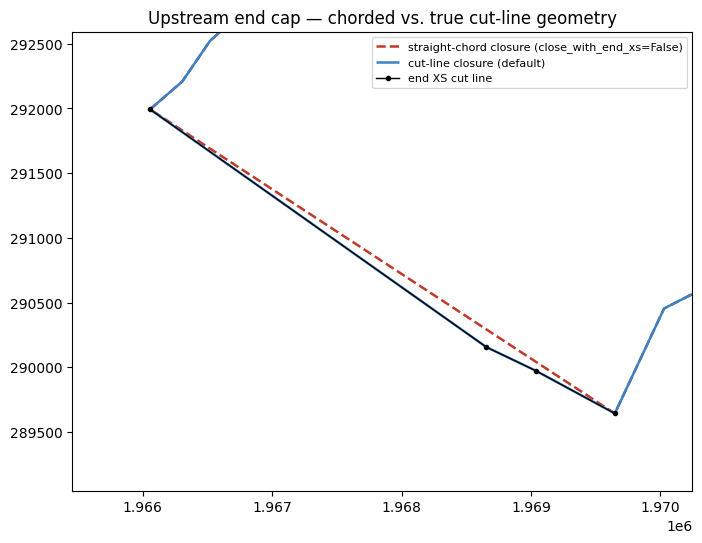

In [6]:
chorded = HdfXsec.get_1d_footprint(geom_hdf, close_with_end_xs=False)

xs_all = HdfXsec.get_cross_sections(geom_hdf)
reach_key = (footprint_1d.iloc[0]["River"], footprint_1d.iloc[0]["Reach"])
reach_xs = xs_all[(xs_all["River"] == reach_key[0]) & (xs_all["Reach"] == reach_key[1])]
end_cut = reach_xs.geometry.iloc[0]  # upstream end cross section

print(f"ring vertices  chorded={len(chorded.geometry.iloc[0].exterior.coords)}  "
      f"cut-line closed={len(footprint_1d.geometry.iloc[0].exterior.coords)}")
print(f"end cut line has {len(end_cut.coords)} vertices "
      f"({len(end_cut.coords) - 2} interior)")

# Every interior vertex of the end cut line must appear in the closed ring.
ring = {(round(x, 4), round(y, 4)) for x, y in footprint_1d.geometry.iloc[0].exterior.coords}
interior = [(round(x, 4), round(y, 4)) for x, y in list(end_cut.coords)[1:-1]]
assert all(pt in ring for pt in interior), "end cut-line vertices missing from footprint"
assert footprint_1d.geometry.is_valid.all()
print("\nChecks passed: end cut-line geometry is preserved in the footprint.")

minx, miny, maxx, maxy = end_cut.buffer(600).bounds
fig, ax = plt.subplots(figsize=(8, 6))
chorded.boundary.plot(ax=ax, color="#c0392b", linestyle="--", linewidth=1.8,
                      label="straight-chord closure (close_with_end_xs=False)")
footprint_1d.boundary.plot(ax=ax, color="#3b82c4", linewidth=1.8,
                           label="cut-line closure (default)")
ax.plot(*end_cut.xy, color="black", linewidth=1.0, marker="o", markersize=3,
        label="end XS cut line")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Upstream end cap — chorded vs. true cut-line geometry")
ax.set_aspect("equal")
ax.legend(loc="best", fontsize=8)
plt.show()

### The overall model extent (upgraded `get_project_extent`)

`HdfProject.get_project_extent(..., geometry_type='footprint')` (the new default)
unions the 2D perimeters with the 1D reach footprints into the true model extent.
Pass `buffer_percent=0` for the raw footprint. The `include_1d` / `include_2d` flags
carve out the 1D-only and 2D-only extents. For comparison, `geometry_type='bbox'`
returns the legacy buffered bounding box.

In [7]:
overall, overall_bounds = HdfProject.get_project_extent(geom_hdf, buffer_percent=0.0)
extent_1d_only, _ = HdfProject.get_project_extent(geom_hdf, include_2d=False, buffer_percent=0.0)
extent_2d_only, _ = HdfProject.get_project_extent(geom_hdf, include_1d=False, buffer_percent=0.0)
bbox, bbox_bounds = HdfProject.get_project_extent(geom_hdf, geometry_type="bbox", buffer_percent=50.0)

describe(overall, "overall footprint (1D + 2D)")
describe(extent_1d_only, "1D-only extent")
describe(extent_2d_only, "2D-only extent")
describe(bbox, "legacy bbox (buffered 50%)")

overall_area = float(overall.geometry.area.sum())
bbox_area = float(bbox.geometry.area.sum())
print(f"\nThe true footprint is {bbox_area / overall_area:.1f}x smaller than the bounding box.")

# Sanity checks (the notebook doubles as a functional test).
assert not overall.empty and overall.geometry.is_valid.all()
assert extent_2d_only.geometry.iloc[0].geom_type in ("Polygon", "MultiPolygon")
assert overall_area <= bbox_area
print("\nChecks passed.")

  overall footprint (1D + 2D): rows=1 types=['Polygon'] area=879,976,583 valid=True
  1D-only extent: rows=1 types=['Polygon'] area=707,534,339 valid=True
  2D-only extent: rows=1 types=['MultiPolygon'] area=172,401,558 valid=True
  legacy bbox (buffered 50%): rows=1 types=['Polygon'] area=15,282,299,978 valid=True

The true footprint is 17.4x smaller than the bounding box.

Checks passed.


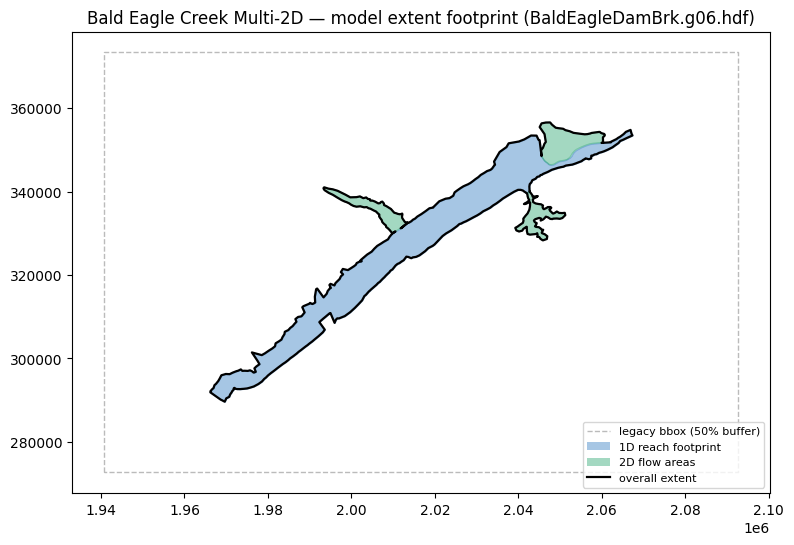

In [8]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 8))
bbox.boundary.plot(ax=ax, color="#bbb", linestyle="--", linewidth=1.0, zorder=1)
footprint_1d.plot(ax=ax, color="#3b82c4", alpha=0.45, edgecolor="#3b82c4", zorder=2)
mesh_areas.plot(ax=ax, color="#33aa77", alpha=0.45, edgecolor="#33aa77", zorder=2)
overall.boundary.plot(ax=ax, color="black", linewidth=1.6, zorder=3)
ax.set_title(f"Bald Eagle Creek Multi-2D — model extent footprint ({geom_hdf.name})")
ax.set_aspect("equal")
ax.legend(handles=[
    Line2D([0], [0], color="#bbb", linestyle="--", linewidth=1.0, label="legacy bbox (50% buffer)"),
    Patch(facecolor="#3b82c4", alpha=0.45, label="1D reach footprint"),
    Patch(facecolor="#33aa77", alpha=0.45, label="2D flow areas"),
    Line2D([0], [0], color="black", linewidth=1.6, label="overall extent"),
], loc="lower right", fontsize=8)
plt.show()

## Example 2: 1D + 2D model (Muncie)

Muncie pairs a 2D flow area with a 1D river, cross sections, and inline structures in one geometry. The figure below layers the whole composition — 2D mesh area and faces, the 1D river and cross sections, and the structures — then draws the 1D, 2D, and overall extent outlines. Because the 1D and 2D domains overlap, combining their footprints leaves thin sliver gaps, which the new `fill_holes` option removes.

In [9]:
muncie = extract_or_reuse("Muncie", "extent_demo")
init_ras_project(muncie, "6.6")

muncie_geom = None
for candidate in find_geom_hdfs(muncie):
    if HdfMesh.get_mesh_area_names(candidate):
        muncie_geom = candidate
        break
print("Muncie 2D geometry:", muncie_geom.name)

# Model composition: the 2D mesh (area + faces) plus the 1D river, cross
# sections, and inline structures that share the same geometry.
muncie_mesh = HdfMesh.get_mesh_areas(muncie_geom)
muncie_faces = HdfMesh.get_mesh_cell_faces(muncie_geom)
muncie_river = HdfXsec.get_river_centerlines(muncie_geom)
muncie_xs = HdfXsec.get_cross_sections(muncie_geom)
muncie_struct = HdfStruc.get_structures(muncie_geom)

# 1D-only, 2D-only, and combined extents (fill_holes on by default).
muncie_1d, _ = HdfProject.get_project_extent(muncie_geom, include_2d=False, buffer_percent=0.0)
muncie_2d, _ = HdfProject.get_project_extent(muncie_geom, include_1d=False, buffer_percent=0.0)
muncie_full, _ = HdfProject.get_project_extent(muncie_geom, buffer_percent=0.0)
muncie_full_holes, _ = HdfProject.get_project_extent(
    muncie_geom, buffer_percent=0.0, fill_holes=False)

print("CRS:", muncie_mesh.crs.name if muncie_mesh.crs else None)
describe(muncie_mesh, "2D perimeter")
describe(muncie_faces, "2D mesh faces")
describe(muncie_xs, "1D cross sections")
describe(muncie_struct, "structures")
describe(muncie_full, "full footprint (1D + 2D)")

# Combining 1D and 2D leaves thin interior sliver gaps where the two boundaries
# overlap without aligning exactly. fill_holes=True (default) removes them.
holes_default = HdfProject._count_holes(muncie_full.geometry.iloc[0])
holes_kept = HdfProject._count_holes(muncie_full_holes.geometry.iloc[0])
print("interior holes  fill_holes=True:", holes_default, " fill_holes=False:", holes_kept)

assert not muncie_2d.empty and muncie_2d.geometry.is_valid.all()
assert holes_default == 0 and holes_kept > 0, "fill_holes should remove the slivers"
print("Checks passed.")

Muncie 2D geometry: Muncie.g02.hdf


CRS: NAD83 / Indiana East (ftUS)
  2D perimeter: rows=1 types=['Polygon'] area=13,709,793 valid=True
  2D mesh faces: rows=11164 types=['LineString'] area=0 valid=True
  1D cross sections: rows=61 types=['LineString'] area=0 valid=True
  structures: rows=2 types=['LineString'] area=0 valid=True
  full footprint (1D + 2D): rows=1 types=['Polygon'] area=25,580,805 valid=True
interior holes  fill_holes=True: 0  fill_holes=False: 12
Checks passed.


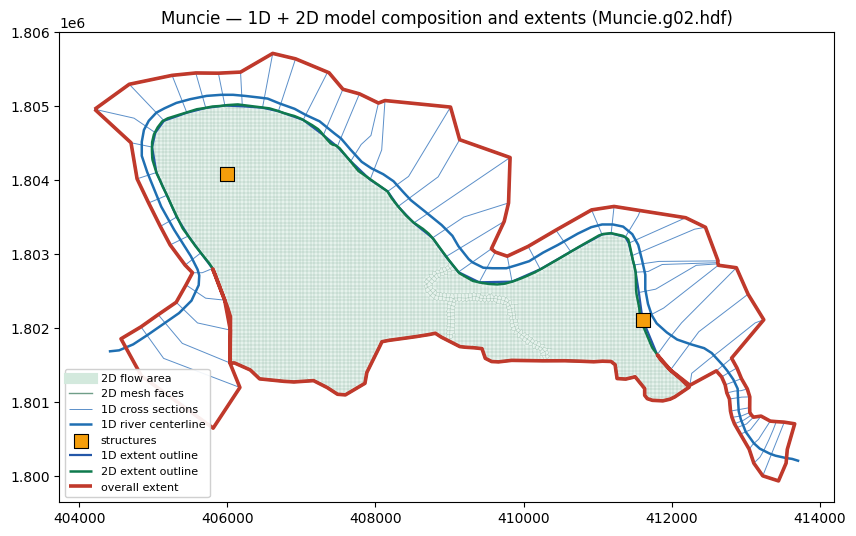

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 9))
# 2D mesh: filled area with the cell faces drawn on top.
muncie_mesh.plot(ax=ax, color="#d3e9dd", alpha=0.55, edgecolor="none", zorder=0)
muncie_faces.plot(ax=ax, color="#6f9e88", linewidth=0.25, alpha=0.75, zorder=1)
# 1D model: cross sections, river centerline, and inline structures.
muncie_xs.plot(ax=ax, color="#5b8fc9", linewidth=0.7, zorder=2, label="1D cross sections")
muncie_river.plot(ax=ax, color="#1f6fb2", linewidth=1.8, zorder=3, label="1D river centerline")
struct_pts = muncie_struct.geometry.centroid
ax.scatter(struct_pts.x, struct_pts.y, s=90, marker="s", facecolor="#f59e0b",
           edgecolor="black", linewidth=0.8, zorder=6, label="structures")
# Extents: 1D and 2D outlines in different colors, overall on top in a contrasting color.
muncie_1d.boundary.plot(ax=ax, color="#2457a8", linewidth=1.6, zorder=4, label="1D extent outline")
muncie_2d.boundary.plot(ax=ax, color="#0f7a4d", linewidth=1.8, zorder=4, label="2D extent outline")
muncie_full.boundary.plot(ax=ax, color="#c0392b", linewidth=2.6, zorder=5, label="overall extent")

# Add area/face swatches to the legend (plot() of fills/many lines does not auto-label).
handles, labels = ax.get_legend_handles_labels()
handles = [Line2D([0], [0], color="#d3e9dd", linewidth=8),
           Line2D([0], [0], color="#6f9e88", linewidth=1)] + handles
labels = ["2D flow area", "2D mesh faces"] + labels
ax.legend(handles, labels, loc="lower left", fontsize=8, framealpha=0.92)
ax.set_title(f"Muncie — 1D + 2D model composition and extents ({muncie_geom.name})")
ax.set_aspect("equal")
plt.show()

### Removing 1D/2D sliver gaps (`fill_holes`)

Where the 1D reach footprint runs alongside the 2D flow area, the union of the two boundaries leaves thin interior **sliver gaps** — they are interior rings (holes) in the combined polygon, not real openings in the model. `get_project_extent(..., fill_holes=True)` (the default) drops those interior rings; the outer boundary and every genuinely separate part are untouched. Zoom in on the largest sliver to see it close.

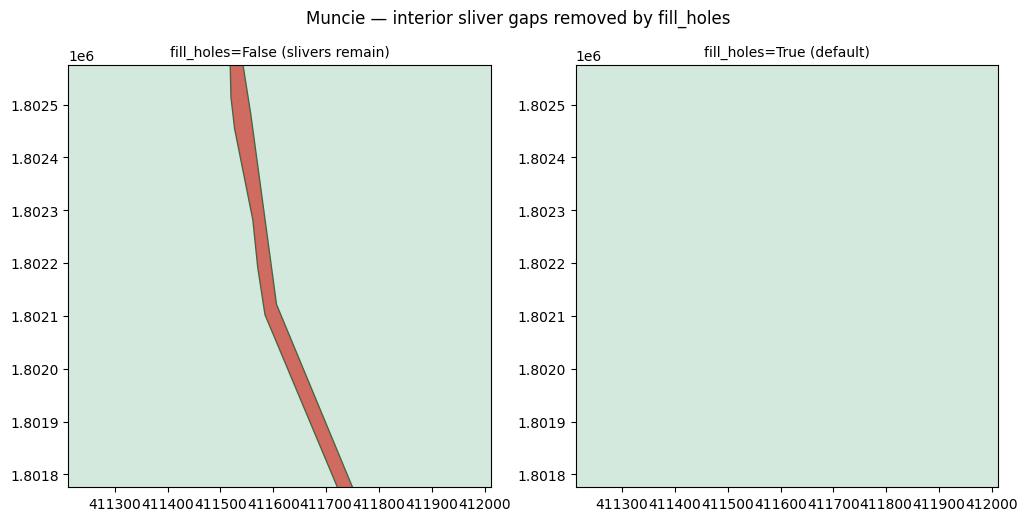

Filled 12 interior sliver(s); area change 0.221%


In [11]:
import geopandas as gpd
from shapely.geometry import Polygon

g_holes = muncie_full_holes.geometry.iloc[0]
g_filled = muncie_full.geometry.iloc[0]
biggest = max(g_holes.interiors, key=lambda r: Polygon(r).area)
cx, cy = Polygon(biggest).centroid.x, Polygon(biggest).centroid.y
pad = 400

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, g, ttl in [(axes[0], g_holes, "fill_holes=False (slivers remain)"),
                   (axes[1], g_filled, "fill_holes=True (default)")]:
    gpd.GeoSeries([g]).plot(ax=ax, color="#d3e9dd", edgecolor="#0f7a4d", linewidth=1.0)
    for ring in getattr(g, "interiors", []):
        gpd.GeoSeries([Polygon(ring)]).plot(ax=ax, color="#c0392b", alpha=0.75)
    ax.set_xlim(cx - pad, cx + pad); ax.set_ylim(cy - pad, cy + pad)
    ax.set_aspect("equal"); ax.set_title(ttl, fontsize=10)
fig.suptitle("Muncie — interior sliver gaps removed by fill_holes", fontsize=12)
plt.show()

assert HdfProject._count_holes(g_filled) == 0
assert g_filled.area >= g_holes.area  # filling holes only adds the gap area
print(f"Filled {len(g_holes.interiors)} interior sliver(s); "
      f"area change {100 * (g_filled.area - g_holes.area) / g_holes.area:.3f}%")

## Authoring edge lines into the geometry HDF (no RASMapper GUI)

The `edge_source='stored'` path above needs a model that already carries
`Geometry/River Edge Lines`. This example ships without them, and ras-commander does not
write an approximation into the HDF: HEC-RAS stamps the layer with a `Source Data Hash`
over the cross-section geometry, and a hand-written layer that lacks a valid hash may be
silently recomputed. Edge lines that HEC-RAS honors come from HEC-RAS.

`RasGeometryCompute.generate_edge_lines()` runs its real bank-line-anchored offset-curve
algorithm **in-process via pythonnet** (RasMapperLib) -- no GUI, no subprocess. It mutates
the geometry HDF in place, so we run it on a disposable copy and skip cleanly when HEC-RAS
is unavailable. See `234_rasmapper_geometry_completion.ipynb` for the full picture
(interpolation surface, flow paths, validation diagnostics, reach-length auditing); on
Linux, `RasProcess.compute_geometry()` is the RasProcess.exe + Wine equivalent.

In [12]:
import h5py

from ras_commander import RasPrj, RasGeometryCompute
from ras_commander.dotnet.clr_bootstrap import is_hecras_available

if not is_hecras_available():
    print("HEC-RAS / pythonnet not available - skipping headless edge-line authoring.")
else:
    # Fresh copy so the examples above are untouched.
    author_project = extract_or_reuse("BaldEagleCrkMulti2D", "edge_author")
    author_ras = RasPrj()
    init_ras_project(author_project, "6.6", ras_object=author_ras)
    author_geom = None
    for candidate in find_geom_hdfs(author_project):
        xs = HdfXsec.get_cross_sections(candidate, ras_object=author_ras)
        if xs is not None and not xs.empty:
            author_geom = candidate
            break
    print("Authoring into:", author_geom.name)

    before = HdfXsec.get_river_edge_lines(author_geom)
    print("stored edge lines before:", 0 if before is None or before.empty else len(before))

    result = RasGeometryCompute.generate_edge_lines(author_geom, ras_object=author_ras)
    print(f"generate_edge_lines: success={result.success} elapsed={result.elapsed_seconds:.1f}s")

    # HEC-RAS-authored: no Attributes dataset, and a group-level Source Data Hash.
    # Bank side is derived from row order (Left, Right per reach), as HEC-RAS does.
    genuine = HdfXsec.get_river_edge_lines(author_geom)
    describe(genuine, "stored edge lines after")
    print("bank sides:", list(genuine["bank_side"]))

    # The stored-source footprint now works.
    fp_stored = HdfXsec.get_1d_footprint(author_geom, edge_source="stored", ras_object=author_ras)
    describe(fp_stored, "footprint (edge_source='stored')")

    with h5py.File(author_geom, "r") as f:
        grp = f["Geometry/River Edge Lines"]
        assert "Source Data Hash" in grp.attrs, "HEC-RAS stamps the layer with its hash"
        assert "Attributes" not in grp, "HEC-RAS writes no Attributes for this layer"

    assert result.success and not genuine.empty
    assert list(genuine["bank_side"]) == ["Left" if i % 2 == 0 else "Right"
                                          for i in range(len(genuine))]
    assert set(fp_stored["source"]) == {"stored_edge_lines"}
    print("")
    print("Checks passed: HEC-RAS authored real edge lines headlessly, "
          "and they drive the stored footprint path.")

Authoring into: BaldEagleDamBrk.g06.hdf
stored edge lines before: 2
generate_edge_lines: success=True elapsed=0.0s
  stored edge lines after: rows=2 types=['LineString'] area=0 valid=True
bank sides: ['Left', 'Right']
  footprint (edge_source='stored'): rows=1 types=['Polygon'] area=710,952,219 valid=True

Checks passed: HEC-RAS authored real edge lines headlessly, and they drive the stored footprint path.


## Key takeaways

- **`HdfProject.get_project_extent(geometry_type='footprint')`** returns the true model
  extent polygon (1D reach footprints + 2D perimeters), replacing the old
  bounding-box-only behavior. Use `geometry_type='bbox'` for the legacy buffered box
  (still used internally for precipitation/terrain download windows).
- **`include_1d` / `include_2d`** slice the extent into 1D-only or 2D-only footprints;
  multiple areas or reaches produce a multipart polygon.
- **`HdfXsec.get_1d_footprint()`** builds the 1D corridor from river edge lines, and
  **`HdfXsec.generate_river_edge_lines()`** derives those edge lines from cross-section
  end points when the model has none stored.
- The reach ring is **closed on the end cross sections' real cut-line geometry**, so bent
  cut lines are preserved. `close_with_end_xs=False` restores the straight-chord closure.
- **`RasGeometryCompute.generate_edge_lines()`** authors HEC-RAS's own edge lines into the
  geometry HDF in-process (pythonnet, no GUI), which is what makes `edge_source='stored'`
  usable on a model that shipped without them. ras-commander deliberately has no
  pure-Python writer for this layer -- only HEC-RAS can stamp the `Source Data Hash`.
- **`fill_holes=True`** (the new default of `get_project_extent`) removes the thin interior sliver gaps left where 1D reach footprints and 2D flow areas overlap. Only interior rings are dropped — disconnected parts of a multipart model are preserved. Pass `fill_holes=False` to keep the raw union.
- Pass **`buffer_percent=0`** for the raw footprint; a positive value buffers it outward.

### Adapting for your project

```python
from ras_commander.hdf import HdfProject

footprint, bounds = HdfProject.get_project_extent("MyModel.g01.hdf", buffer_percent=0.0)
footprint.to_file("model_extent.geojson", driver="GeoJSON")  # or .gpkg / .shp
```